In [1]:
import warnings

warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc
import pandas as pd
import numpy as np
import random
import sc_toolbox
import pertpy 

import rpy2.rinterface_lib.callbacks
import anndata2ri
import logging

from rpy2.robjects import pandas2ri
from rpy2.robjects import r

sc.settings.verbosity = 0
rpy2.rinterface_lib.callbacks.logger.setLevel(logging.ERROR)

pandas2ri.activate()
anndata2ri.activate()

%load_ext rpy2.ipython

In [2]:
%%R
library(edgeR)

Loading required package: limma


# Running on XX cell types

In [3]:
adata_pb = sc.read('./pb_adata_LPC_Mg.h5ad')
adata_pb

AnnData object with n_obs × n_vars = 25 × 17747
    obs: 'publication', 'label', 'cell_type', 'replicate_cat', 'sample', 'sample_rep', 'batch', 'lib_size', 'log_lib_size', 'replicate'
    uns: 'cell_type_colors', 'label_colors', 'log1p', 'pca', 'publication_colors', 'replicate_cat_colors', 'sample_colors', 'sample_rep_colors'
    obsm: 'X_pca'
    varm: 'PCs'
    layers: 'counts'

In [4]:
# Extract the data as a pandas DataFrame
df = adata_pb.obs[['cell_type', 'label']]

# Create a summary table
summary_table = df.groupby(['cell_type', 'label']).size().unstack(fill_value=0)
summary_table

label,ctrl,stim
cell_type,,
BAMs,0,6
Mg,4,9
cycling,0,6


In [5]:
adata_sub= adata_pb[np.in1d(adata_pb.obs['cell_type'], 
                           ['Mg', 'BAMs'])].copy()

print("Dimensions of adata_sub:", adata_sub.shape)

Dimensions of adata_sub: (19, 17747)


In [6]:
pub_map = {
    '(this study)': 'Adams',
    'Pandey et al. 2022': 'Pandey'
}

# Update the 'treatment_meta' column based on the mapping
adata_sub.obs['batch'] = adata_sub.obs['publication'].map(pub_map)

In [7]:
# Concatenate 'individual_lesion_condition' and 'replicate' to create 'sample'
adata_sub.obs['cell_type_sample'] = adata_sub.obs['cell_type'].astype(str) + '_' + adata_sub.obs['sample_rep'].astype(str)

In [8]:
adata_sub.obs[:5]

,publication,label,cell_type,replicate_cat,sample,sample_rep,batch,lib_size,log_lib_size,replicate,cell_type_sample
donor_ctrl_1_0-0-0,(this study),ctrl,Mg,1,ctrl_1,LPC_Saline_2,Adams,230040,12.346008,1,Mg_LPC_Saline_2
donor_ctrl_2_0-0-0,(this study),ctrl,Mg,2,ctrl_2,LPC_Saline_1,Adams,482959,13.087687,2,Mg_LPC_Saline_1
donor_ctrl_4_0-0-0,Pandey et al. 2022,ctrl,Mg,4,ctrl_4,LPC_ctrl_2,Pandey,496543,13.115425,4,Mg_LPC_ctrl_2
donor_ctrl_5_0-0-0,Pandey et al. 2022,ctrl,Mg,5,ctrl_5,LPC_ctrl_1,Pandey,2344123,14.667422,5,Mg_LPC_ctrl_1
donor_stim_1_0-0-0,(this study),stim,Mg,1,stim_1,LPC_7d_2,Adams,2682382,14.802216,1,Mg_LPC_7d_2


# Subset for demyelination and remyelination MOL2 data

In [9]:
# Unique values in the 'condition' column
unique_conditions = adata_sub.obs['cell_type_sample'].unique()
for condition in unique_conditions:
    print(condition)

Mg_LPC_Saline_2
Mg_LPC_Saline_1
Mg_LPC_ctrl_2
Mg_LPC_ctrl_1
Mg_LPC_7d_2
Mg_LPC_5d_4
Mg_LPC_7d_1
Mg_LPC_5d_1
Mg_LPC_5d_3
Mg_LPC_28d_3
Mg_LPC_28d_1
Mg_LPC_5d_2
Mg_LPC_28d_2
BAMs_LPC_7d_2
BAMs_LPC_5d_4
BAMs_LPC_7d_1
BAMs_LPC_5d_1
BAMs_LPC_5d_3
BAMs_LPC_5d_2


In [10]:
adata_sub= adata_sub[np.in1d(adata_sub.obs['cell_type_sample'], 
                           [
                            'Mg_LPC_Saline_2',
                            'Mg_LPC_Saline_1',
                            'Mg_LPC_ctrl_2',
                            'Mg_LPC_ctrl_1',
                            'BAMs_LPC_7d_2',
                            'BAMs_LPC_5d_4',
                            'BAMs_LPC_5d_3',
                            'BAMs_LPC_7d_1',
                            'BAMs_LPC_5d_2',
                            'BAMs_LPC_5d_1'                 
                           ])].copy()

print("Dimensions of adata_sub:", adata_sub.shape)

Dimensions of adata_sub: (10, 17747)


In [11]:
# Check if the 'sample_rep' column exists
if 'sample_rep' in adata_sub.obs.columns:
    # Set the 'sample_rep' column as the index
    adata_sub.obs.set_index('sample_rep', inplace=True)
else:
    print("The column 'sample_rep' does not exist in adata_sub.obs.")

adata_sub.obs.index.name = None

In [12]:
adata_sub.obs

,publication,label,cell_type,replicate_cat,sample,batch,lib_size,log_lib_size,replicate,cell_type_sample
LPC_Saline_2,(this study),ctrl,Mg,1,ctrl_1,Adams,230040,12.346008,1,Mg_LPC_Saline_2
LPC_Saline_1,(this study),ctrl,Mg,2,ctrl_2,Adams,482959,13.087687,2,Mg_LPC_Saline_1
LPC_ctrl_2,Pandey et al. 2022,ctrl,Mg,4,ctrl_4,Pandey,496543,13.115425,4,Mg_LPC_ctrl_2
LPC_ctrl_1,Pandey et al. 2022,ctrl,Mg,5,ctrl_5,Pandey,2344123,14.667422,5,Mg_LPC_ctrl_1
LPC_7d_2,(this study),stim,BAMs,1,stim_1,Adams,229152,12.342141,1,BAMs_LPC_7d_2
LPC_5d_4,Pandey et al. 2022,stim,BAMs,11,stim_11,Pandey,14508038,16.490213,11,BAMs_LPC_5d_4
LPC_7d_1,(this study),stim,BAMs,2,stim_2,Adams,560715,13.236968,2,BAMs_LPC_7d_1
LPC_5d_1,Pandey et al. 2022,stim,BAMs,3,stim_3,Pandey,3684988,15.119778,3,BAMs_LPC_5d_1
LPC_5d_3,Pandey et al. 2022,stim,BAMs,4,stim_4,Pandey,15289272,16.542662,4,BAMs_LPC_5d_3
LPC_5d_2,Pandey et al. 2022,stim,BAMs,7,stim_7,Pandey,3703750,15.124856,7,BAMs_LPC_5d_2


# Rename the MOL clusters for NEW letter based nomenclature

In [13]:
#Check the counts data
print(adata_sub.X[:5, :5])

[[ 0  0  4  0 17]
 [ 0 10  4  4 20]
 [ 0 12  2  3 16]
 [ 0 26  4 18 60]
 [ 0  2  5  1 30]]


# Start R code: QC of log transformation

In [14]:
%%R -i adata_sub

# Concatenate label and cell type for group factor
group <- colData(adata_sub)$label #ctrl or stim
replicate <- colData(adata_sub)$replicate #replicate number
batch <- colData(adata_sub)$batch

treatments <- data.frame("Group"=group, "Reps"=replicate, "Batch"= batch)
print(treatments)

             Group Reps  Batch
LPC_Saline_2  ctrl    1  Adams
LPC_Saline_1  ctrl    2  Adams
LPC_ctrl_2    ctrl    4 Pandey
LPC_ctrl_1    ctrl    5 Pandey
LPC_7d_2      stim    1  Adams
LPC_5d_4      stim   11 Pandey
LPC_7d_1      stim    2  Adams
LPC_5d_1      stim    3 Pandey
LPC_5d_3      stim    4 Pandey
LPC_5d_2      stim    7 Pandey


In [15]:
%%R

#Create a DGElist object using the anndata counts in 'X'
x <- DGEList(assay(adata_sub, "X"), group=colData(adata_sub)$label)

samplenames <- colnames(x$counts)

print("Dimensions before subsetting:")
print(dim(x))

# Check counts per group before filtering
print(table(x$samples$group))

[1] "Dimensions before subsetting:"
[1] 17747    10

ctrl stim 
   4    6 


In [16]:
%%R

cd <- x$samples$group
print(cd)

# Adjust for batch-- ie publication in the model matrix
design <- model.matrix(~0 + cd)
print(design)

 [1] ctrl ctrl ctrl ctrl stim stim stim stim stim stim
Levels: ctrl stim
   cdctrl cdstim
1       1      0
2       1      0
3       1      0
4       1      0
5       0      1
6       0      1
7       0      1
8       0      1
9       0      1
10      0      1
attr(,"assign")
[1] 1 1
attr(,"contrasts")
attr(,"contrasts")$cd
[1] "contr.treatment"



In [17]:
%%R

# More strict removal of genes, tried group, pub and batch
keep.expr <- filterByExpr(x, design)
x2 <- x[keep.expr,, keep.lib.sizes=FALSE]
dim(x2)

[1] 9786   10


In [18]:
%%R

## OLD DON"T USE THIS

keep.exprs <- filterByExpr(x, group=batch)
b <- x[keep.exprs,, keep.lib.sizes=FALSE]
dim(b)

[1] 9786   10


In [19]:
%%R
#X is before trimming, Y is after trimming
L <- mean(x2$samples$lib.size) * 1e-6
M <- median(x2$samples$lib.size) * 1e-6
c(L, M)

[1] 4.124533 1.431656


In [20]:
%%R
## Calc norm factors before to normalize library sizes, then cpm divides counts by lib sizes
#X is before trimming, Y is after trimming, X2 is also trimmed but differently
x2 <- calcNormFactors(x2, method = "TMM")
x2$samples$norm.factors

 [1] 1.6083712 1.5269714 1.0175873 0.9695818 1.5183920 0.6742746 1.3924667
 [8] 0.7622082 0.5884111 0.6454561


In [21]:
%%R
#X2 is the norm lib sizes and trimmed
cpm <- edgeR::cpm(x2, log=FALSE, prior.counts=3)
lcpm <- edgeR::cpm(x2, log=TRUE, prior.count=3)

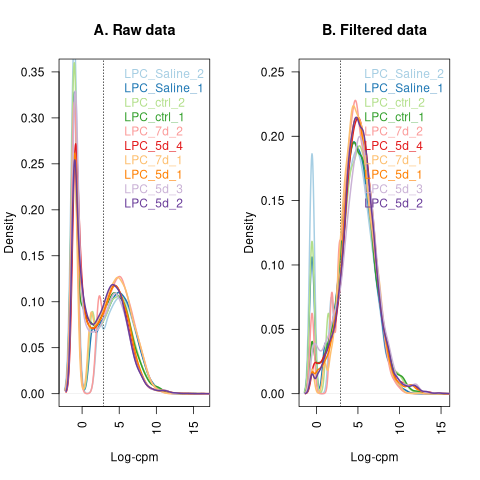

In [22]:
%%R
lcpm.cutoff <- log2(10/M + 2/L)
library(RColorBrewer)
nsamples <- ncol(x2)
col <- brewer.pal(nsamples, "Paired")

par(mfrow=c(1,2))

lcpm <- edgeR::cpm(x, log=TRUE)
plot(density(lcpm[,1]), col=col[1], lwd=2, ylim=c(0,0.35), las=2, main="", xlab="")
title(main="A. Raw data", xlab="Log-cpm")
abline(v=lcpm.cutoff, lty=3)
for (i in 2:nsamples){
  den <- density(lcpm[,i])
  lines(den$x, den$y, col=col[i], lwd=2)
}
legend("topright", samplenames, text.col=col, bty="n")

lcpm <- edgeR::cpm(x2, log=TRUE)
plot(density(lcpm[,1]), col=col[1], lwd=2, ylim=c(0,0.25), las=2, main="", xlab="")
title(main="B. Filtered data", xlab="Log-cpm")
abline(v=lcpm.cutoff, lty=3)
for (i in 2:nsamples){
  den <- density(lcpm[,i])
  lines(den$x, den$y, col=col[i], lwd=2)
}
legend("topright", samplenames, text.col=col, bty="n")

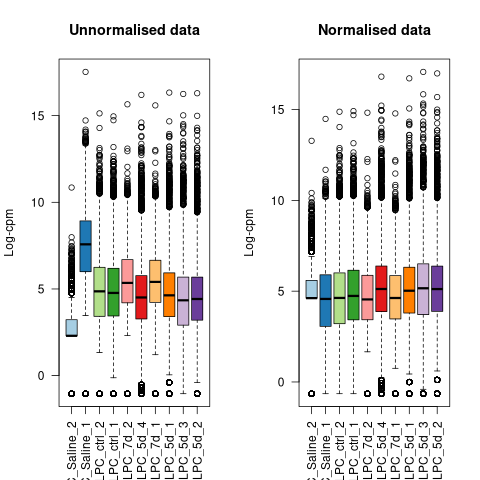

In [23]:
%%R
y2 <- x2
y2$samples$norm.factors <- 1
y2$counts[,1] <- ceiling(y2$counts[,1]*0.05)
y2$counts[,2] <- y2$counts[,2]*5

par(mfrow=c(1,2))
lcpm <- edgeR::cpm(y2, log=TRUE)
boxplot(lcpm, las=2, col=col, main="")
title(main="Unnormalised data", ylab="Log-cpm")

y3 <- calcNormFactors(y2)
y3$samples$norm.factors

lcpm <- edgeR::cpm(y3, log=TRUE)
boxplot(lcpm, las=2, col=col, main="")
title(main="Normalised data", ylab="Log-cpm")

# Show how log transf + batch removal affects the separation of samples:

In [24]:
%%R
cd <- x2$samples$group
print(cd)

 [1] ctrl ctrl ctrl ctrl stim stim stim stim stim stim
Levels: ctrl stim


In [25]:
%%R
#Make new count matrix with log counts and DGE data from X2 (trimmed, normfactors)
x3 <- x2
x3$counts <- lcpm

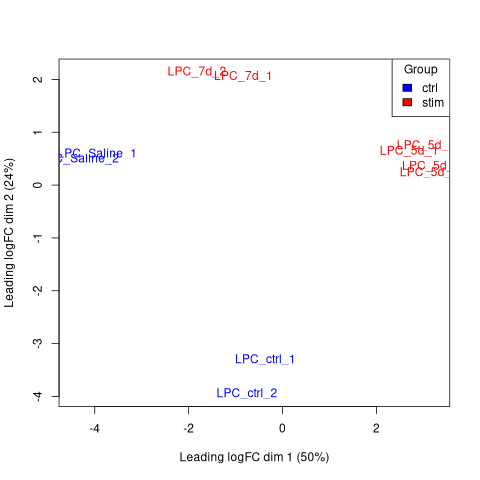

In [26]:
%%R
# Assuming 'group' is stored in y$samples dataframe
group <- x2$samples$group

# Generate a numeric vector from group factors (if not already factor, convert it)
group_factor <- as.factor(group)
group_colors <- as.numeric(group_factor)  # This converts factors to unique integers

# Define a set of colors corresponding to the factors
# Example: If you have two groups, you could define two colors
colors <- c("blue", "red")  # Adjust the number and colors based on your actual groups

# Use these colors in your plotMDS
plotMDS(x2, col = colors[group_colors])

# Adding a legend for clarity
legend("topright", legend=levels(group_factor), fill=colors, title="Group")

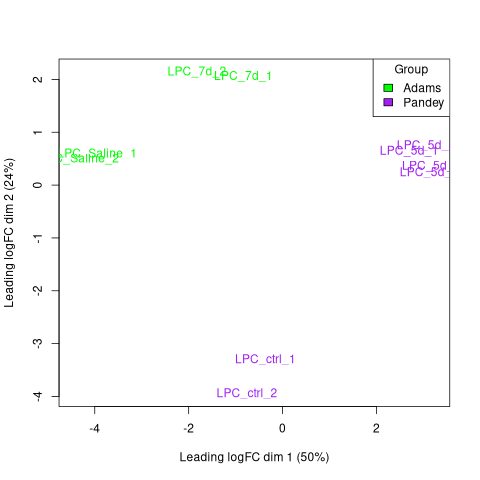

In [27]:
%%R
# Generate a numeric vector from group factors (if not already factor, convert it)
pub_factor <- as.factor(batch)
pub_colors <- as.numeric(pub_factor)  # This converts factors to unique integers

# Define a set of colors corresponding to the factors
# Example: If you have two groups, you could define two colors
colors <- c("green", "purple")  # Adjust the number and colors based on your actual groups

# Use these colors in your plotMDS
plotMDS(x2, col = colors[pub_colors])

# Adding a legend for clarity
legend("topright", legend=levels(pub_factor), fill=colors, title="Group")

In [28]:
%%R

x3$samples

             group lib.size norm.factors
LPC_Saline_2  ctrl   225663    1.6083712
LPC_Saline_1  ctrl   473461    1.5269714
LPC_ctrl_2    ctrl   489319    1.0175873
LPC_ctrl_1    ctrl  2314871    0.9695818
LPC_7d_2      stim   223516    1.5183920
LPC_5d_4      stim 14411684    0.6742746
LPC_7d_1      stim   548441    1.3924667
LPC_5d_1      stim  3659083    0.7622082
LPC_5d_3      stim 15221605    0.5884111
LPC_5d_2      stim  3677686    0.6454561


In [29]:
%%R
# Adjust for batch-- ie publication in the model matrix
design <- model.matrix(~0 + cd)
design

   cdctrl cdstim
1       1      0
2       1      0
3       1      0
4       1      0
5       0      1
6       0      1
7       0      1
8       0      1
9       0      1
10      0      1
attr(,"assign")
[1] 1 1
attr(,"contrasts")
attr(,"contrasts")$cd
[1] "contr.treatment"



In [30]:
%%R
contr.matrix <- makeContrasts(cdstim - cdctrl, levels = colnames(design))
contr.matrix

        Contrasts
Levels   cdstim - cdctrl
  cdctrl              -1
  cdstim               1


In [31]:
%%R
# Convert to CPM and log2 transformation. 
logCPM <- edgeR::cpm(x2, log=TRUE, prior.count=3)

In [32]:
%%R
#Batch is set to the publication of origin to remove effects between sample origins
logCPM_no_batch <- removeBatchEffect(logCPM, batch=batch) 

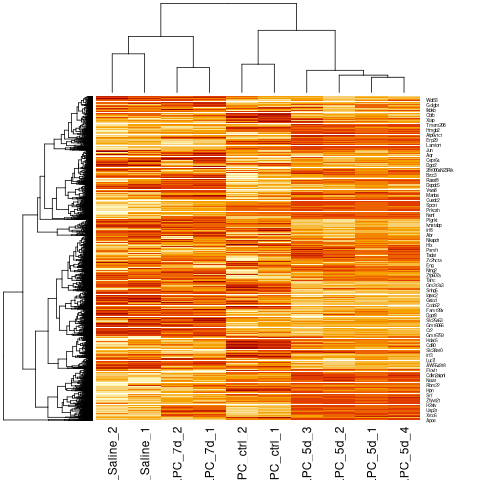

In [33]:
%%R
heatmap(logCPM)

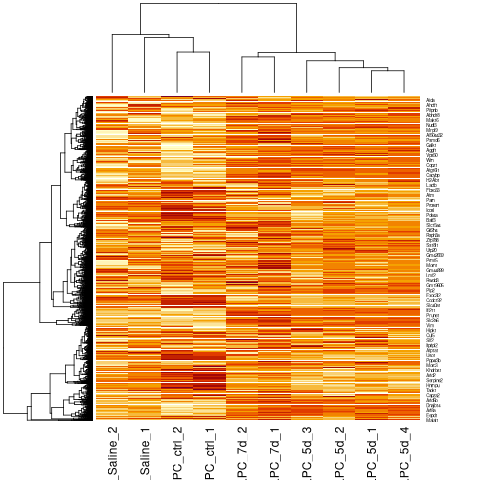

In [34]:
%%R
heatmap(logCPM_no_batch)

# Voom with quality weights

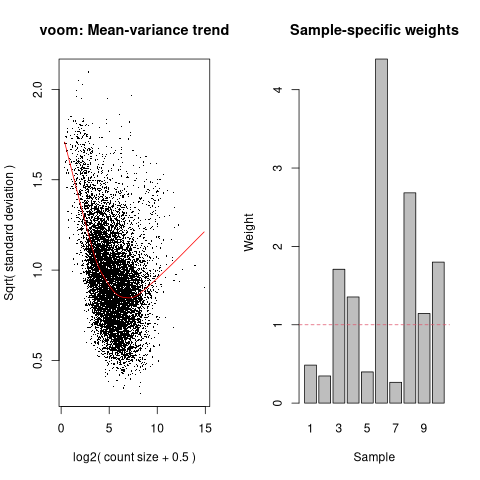

In [35]:
%%R
y <- voomWithQualityWeights(x2$counts, design, plot=TRUE)

In [36]:
%%R
corfit <- duplicateCorrelation(y, design, block=batch)
corfit$consensus.correlation

[1] 0.4656717


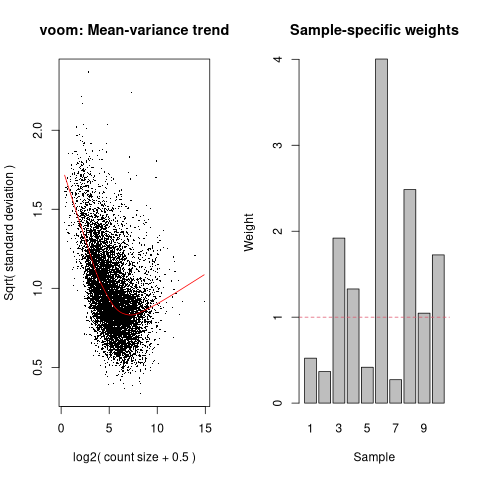

In [37]:
%%R
y2 <- voomWithQualityWeights(x2$counts, design, plot=TRUE, block=batch, correlation=corfit$consensus)

In [38]:
%%R
corfit2 <- duplicateCorrelation(y2,design,block=batch, weights=y2$targets$sample.weights)
corfit2$consensus.correlation

[1] 0.5957188


In [39]:
%%R
fit <- lmFit(y2, design, block=batch, correlation=corfit2$consensus)

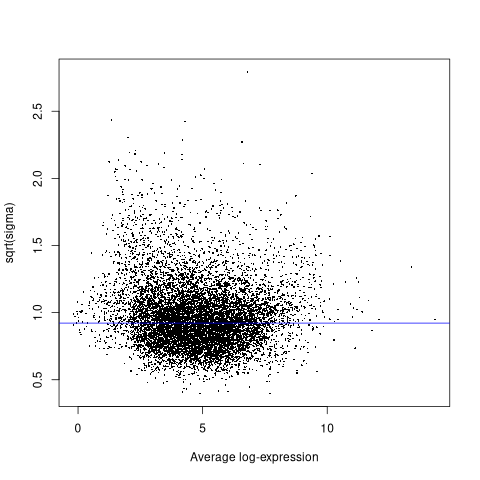

In [40]:
%%R
contr <- makeContrasts(cdstim - cdctrl, levels = colnames(coef(fit)))
tmp <- contrasts.fit(fit, contr)
tmp2 <- eBayes(tmp)

plotSA(tmp2, xlab = "Average log-expression", ylab = "sqrt(sigma)", zero.weights = FALSE,
       pch = 16, cex = 0.3, col = c("black","red"))

In [41]:
%%R
# Retrieve the top results without sorting by p-value directly
tt <- topTable(tmp2, sort.by = "P", n = Inf)
head(tt, 10)

             logFC  AveExpr         t      P.Value    adj.P.Val        B
Pard3b   -6.676340 4.516703 -40.34751 1.539252e-14 1.506312e-10 22.87087
Rtn4rl1  -6.676376 3.781436 -32.70249 2.039465e-13 8.169610e-10 20.43870
Sall1    -7.238846 3.593838 -32.15979 2.504479e-13 8.169610e-10 20.22825
Slc40a1  -5.495487 3.272162 -29.80532 6.361467e-13 1.556333e-09 19.60854
Tjp1     -6.955847 3.821797 -28.12929 1.291834e-12 1.655170e-09 18.81722
Snta1    -4.428345 4.769659 -28.09160 1.313193e-12 1.655170e-09 19.26227
Ifitm10  -5.292311 5.498133 -27.90642 1.423814e-12 1.655170e-09 19.24289
Cables1  -6.158330 4.107414 -27.76734 1.513503e-12 1.655170e-09 19.09042
Magi1    -8.554367 4.423943 -27.58621 1.639560e-12 1.655170e-09 18.49890
BC035044 -5.503586 3.387390 -27.51609 1.691366e-12 1.655170e-09 18.66760


In [42]:
%%R
length(which(tt$adj.P.Val < 0.05))

[1] 5264


In [43]:
%%R
# Calculate the number of genes with adj.P.Val < 0.05 and |logFC| > 1
significant_genes <- tt[tt$adj.P.Val < 0.05 & abs(tt$logFC) > 0.7, ]
num_significant_genes <- nrow(significant_genes)

# Print the number of significant genes
print(num_significant_genes)

[1] 4960


In [44]:
%%R
# Calculate the number of genes with adj.P.Val < 0.05 and |logFC| > 1
significant_genes <- tt[tt$adj.P.Val < 0.05 & abs(tt$logFC) > 1, ]
num_significant_genes <- nrow(significant_genes)

# Print the number of significant genes
print(num_significant_genes)

[1] 4154


In [45]:
%%R
# Calculate the number of genes with adj.P.Val < 0.05 and |logFC| > 1
genes_up <- tt[tt$adj.P.Val < 0.05 & tt$logFC > 1, ]
num_genes_up <- nrow(genes_up)

# Print the number of significant genes
print(num_genes_up)

genes_up_sorted <- genes_up[order(genes_up$logFC, decreasing = TRUE), ]

# View the head of the significant genes data frame
head(genes_up_sorted)

[1] 1241
           logFC  AveExpr         t      P.Value    adj.P.Val          B
Gpnmb  12.773090 8.585059 12.216797 2.781308e-08 7.645471e-07  8.0099248
Fabp5  11.019915 7.260340  6.368454 3.055605e-05 1.785203e-04  2.6670443
Ms4a7   9.966429 6.009466  8.927482 9.373454e-07 1.164356e-05  5.0874857
Pla2g7  9.476923 6.423343  9.017269 8.407810e-07 1.072736e-05  6.1955621
Apoc2   9.140674 4.500373  4.265338 1.019208e-03 3.185555e-03 -0.5493522
Fbxo32  9.033785 5.901237  7.640686 4.898548e-06 4.186655e-05  3.9113237


In [46]:
%%R
if ('Apoe' %in% rownames(genes_up_sorted)) {
    print("gene IS in the index of genes_up_sorted")
} else {
    print("gene is NOT in the index of genes_up_sorted")
}

[1] "gene IS in the index of genes_up_sorted"


In [47]:
%%R
# Calculate the number of genes with adj.P.Val < 0.05 and |logFC| > 1
genes_down <- tt[tt$adj.P.Val < 0.05 & tt$logFC < -1, ]
num_genes_down <- nrow(genes_down)

# Print the number of significant genes
print(num_genes_down)

genes_down_sorted <- genes_down[order(genes_down$logFC, decreasing = FALSE), ]

# View the head of the significant genes data frame
head(genes_down_sorted)

[1] 2913
             logFC  AveExpr          t      P.Value    adj.P.Val         B
Gm10790 -11.413639 3.460281 -10.049509 2.548248e-07 4.349038e-06  6.788235
Chst8   -10.314715 1.849374 -10.241089 2.063842e-07 3.658833e-06  6.842811
Crybb1  -10.233503 3.663958 -16.105822 1.091579e-09 7.522671e-08 12.389098
Sall3   -10.115104 2.404090  -9.426705 5.173613e-07 7.500589e-06  6.159330
Csmd3   -10.039925 6.020295 -24.402935 7.316733e-12 3.409597e-09 17.546582
Asb2     -9.681326 1.794190 -10.067185 2.498822e-07 4.282569e-06  6.583041


# Save output- make sure to rename!

In [48]:
%%R
# Add row names as a new column
tt$gene <- rownames(tt)

# Optionally reorder or select columns
tt <- tt[, c("gene", names(tt)[1:6])]

# Write to CSV file
write.table(tt, file = "./files/LPC_demyel_Mgctrl_v_BAMs_voom_wqw_NEW.csv", row.names = FALSE, sep = ",", quote = FALSE)